<!-- ARTHASAATHI-PROVENANCE -->
> ## ⚠️ This notebook is demo evidence, not the running system
>
> The logic below was migrated to **`ml/src/councils/cashflow/stability.py + income_projection.py + ml/src/decision/montecarlo.py`** and that module is what the application actually executes.
>
> **Role in the system:** Cashflow Council -> Stability & Income Projection, Decision Layer -> Monte Carlo
>
> This notebook is preserved because its stored outputs are the record of the original analysis. **Editing the cells below will not change the system's behaviour** — change the module and its tests instead.
>
> Tests for this logic live under `tests/`, and every agent is covered by the cross-cutting contract suite in `tests/common/test_contracts.py`.


# 💰 Personal Cashflow Simulator
Full pipeline: Transactions → Categorization → Recurring Detector → Holt-Winters → SARIMAX → Statistical Estimator → Cashflow Simulator → Risk Engine → LLM Explanation

## 📦 Install & Import

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
import json
import re
from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta
from collections import defaultdict

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.family'] = 'sans-serif'

print('✅ All libraries loaded')

✅ All libraries loaded


---
## 🧾 STEP 1 — Transactions Input
Provide 10 income values, 10 expense values, and personal context.

In [2]:
# ─────────────────────────────────────────────
# USER INPUT — Edit these values
# ─────────────────────────────────────────────

# Last 10 monthly income values (oldest → newest), in INR
income_values = [52000, 52000, 55000, 52000, 60000, 52000, 52000, 58000, 52000, 70000]

# Last 10 monthly expense values (oldest → newest), in INR
expense_values = [38000, 41000, 39000, 44000, 37000, 42000, 40000, 45000, 38000, 43000]

# Current bank balance, in INR
current_balance = 85000

# Personal context
occupation   = "Software Engineer"   # e.g. Salaried, Teacher, Farmer, Gig Worker
age          = 29
city         = "Mumbai"
dependents   = 1                     # number of dependents
goal         = "Build 6-month emergency fund"

# External factors (free text, comma-separated)
external_factors = "inflation rising, planning a vacation in March, possible job switch"

# Forecast horizon (months)
forecast_months = 6

# ─────────────────────────────────────────────
# Derive date index (last 10 months)
# ─────────────────────────────────────────────
today = datetime.today()
months = [today - relativedelta(months=i) for i in reversed(range(len(income_values)))]
month_labels = [m.strftime('%b %Y') for m in months]

df_hist = pd.DataFrame({
    'month': months,
    'income': income_values,
    'expense': expense_values
})
df_hist['net'] = df_hist['income'] - df_hist['expense']
df_hist.set_index('month', inplace=True)

print('📅 Historical data loaded:')
print(df_hist.to_string())

📅 Historical data loaded:
                            income  expense    net
month                                             
2025-09-14 19:06:16.799122   52000    38000  14000
2025-10-14 19:06:16.799122   52000    41000  11000
2025-11-14 19:06:16.799122   55000    39000  16000
2025-12-14 19:06:16.799122   52000    44000   8000
2026-01-14 19:06:16.799122   60000    37000  23000
2026-02-14 19:06:16.799122   52000    42000  10000
2026-03-14 19:06:16.799122   52000    40000  12000
2026-04-14 19:06:16.799122   58000    45000  13000
2026-05-14 19:06:16.799122   52000    38000  14000
2026-06-14 19:06:16.799122   70000    43000  27000


---
## 🏷️ STEP 2 — Categorization

In [ ]:
# Rule-based categorization of income + expense buckets
# In a real system this would run on raw transactions.
# Here we label each historical row with category tags.

INCOME_CATEGORIES = {
    'Salary':           'recurring',
    'Freelance/Gig':    'variable',
    'Business':         'irregular',
    'Investment':       'variable',
    'Other Income':     'irregular',
}

EXPENSE_CATEGORIES = {
    'Rent/EMI':         'recurring',
    'EMI':         'recurring',
    'Insurance':        'recurring',
    'Utilities':        'seasonal',
    'Groceries':        'seasonal',
    'Fuel/Transport':   'seasonal',
    'Shopping':         'discretionary',
    'Entertainment':    'discretionary',
    'Travel':           'discretionary',
    'Medical':          'irregular',
    'Other Expense':    'irregular',
}

# Simple occupation → income-type mapping
OCC_MAP = {
    'salaried':         ['Salary'],
    'software engineer':['Salary', 'Freelance/Gig'],
    'teacher':          ['Salary'],
    'farmer':           ['Business', 'Other Income'],
    'gig worker':       ['Freelance/Gig'],
    'doctor':           ['Salary', 'Business'],
    'business':         ['Business'],
}

occ_key = occupation.lower()
matched_income_cats = next((v for k, v in OCC_MAP.items() if k in occ_key), ['Salary', 'Other Income'])

print(f'🏷️  Occupation detected    : {occupation}')
print(f'🏷️  Primary income sources : {matched_income_cats}')
print(f'🏷️  All expense categories : {list(EXPENSE_CATEGORIES.keys())}')

🏷️  Occupation detected    : Software Engineer
🏷️  Primary income sources : ['Salary', 'Freelance/Gig']
🏷️  All expense categories : ['Rent/EMI', 'Insurance', 'Utilities', 'Groceries', 'Fuel/Transport', 'Shopping', 'Entertainment', 'Travel', 'Medical', 'Other Expense']


---
## 🔁 STEP 3 — Recurring Detector
Detect fixed/recurring items: Salary, Rent, EMI, Insurance

In [4]:
def detect_recurring(series: pd.Series, cv_threshold: float = 0.10):
    """
    Classify a time-series as recurring if coefficient of variation < threshold.
    Returns: dict with mean, std, cv, is_recurring, forecast
    """
    mean = series.mean()
    std  = series.std()
    cv   = std / mean if mean != 0 else 99
    is_recurring = cv < cv_threshold
    return {
        'mean': round(mean, 2),
        'std':  round(std, 2),
        'cv':   round(cv, 4),
        'is_recurring': is_recurring,
        'forecast': [round(mean, 2)] * forecast_months   # deterministic calendar
    }

# ── Analyse income and expense streams ──────────────────────────────────────
income_series  = pd.Series(income_values,  dtype=float)
expense_series = pd.Series(expense_values, dtype=float)

# Split expense into recurring estimate (60 %) vs variable (40 %) heuristic
# (In a real system you'd split actual transaction rows.)
recurring_expense_pct = 0.60
recurring_exp_series = expense_series * recurring_expense_pct
variable_exp_series  = expense_series * (1 - recurring_expense_pct)

income_recurring  = detect_recurring(income_series)
expense_recurring = detect_recurring(recurring_exp_series)

print('=== Recurring Detector ===')
print(f"Income  — CV: {income_recurring['cv']:.4f}  |  Recurring: {income_recurring['is_recurring']}")
print(f"Rec Exp — CV: {expense_recurring['cv']:.4f}  |  Recurring: {expense_recurring['is_recurring']}")
print(f"\nRecurring income  forecast (next {forecast_months}m): {income_recurring['forecast']}")
print(f"Recurring expense forecast (next {forecast_months}m): {expense_recurring['forecast']}")

=== Recurring Detector ===
Income  — CV: 0.1058  |  Recurring: False
Rec Exp — CV: 0.0676  |  Recurring: True

Recurring income  forecast (next 6m): [np.float64(55500.0), np.float64(55500.0), np.float64(55500.0), np.float64(55500.0), np.float64(55500.0), np.float64(55500.0)]
Recurring expense forecast (next 6m): [np.float64(24420.0), np.float64(24420.0), np.float64(24420.0), np.float64(24420.0), np.float64(24420.0), np.float64(24420.0)]


---
## 📈 STEP 4 — Holt-Winters (Utilities, Fuel, Groceries)

In [5]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

def holt_winters_forecast(series: pd.Series, periods: int, seasonal_periods: int = None):
    """
    Fit Holt-Winters and return forecast array.
    Falls back to double exponential smoothing if series too short for seasonal.
    """
    n = len(series)
    try:
        if seasonal_periods and n >= 2 * seasonal_periods:
            model = ExponentialSmoothing(
                series, trend='add', seasonal='add',
                seasonal_periods=seasonal_periods
            ).fit(optimized=True, use_brute=True)
        else:
            model = ExponentialSmoothing(
                series, trend='add', seasonal=None
            ).fit(optimized=True)
        forecast = model.forecast(periods)
        return [max(0, round(v, 2)) for v in forecast]
    except Exception as e:
        # fallback: simple mean
        return [round(series.mean(), 2)] * periods

# Variable expenses fed into Holt-Winters
hw_forecast = holt_winters_forecast(
    variable_exp_series,
    periods=forecast_months,
    seasonal_periods=4        # quarterly seasonality hint
)

print(f'📈 Holt-Winters variable expense forecast (next {forecast_months}m):')
for i, v in enumerate(hw_forecast, 1):
    print(f'   Month +{i}: ₹{v:,.0f}')

📈 Holt-Winters variable expense forecast (next 6m):
   Month +1: ₹16,160
   Month +2: ₹18,160
   Month +3: ₹15,547
   Month +4: ₹17,280
   Month +5: ₹16,400
   Month +6: ₹18,400


---
## 📊 STEP 5 — SARIMAX (Teacher / Farmer / Gig Income)

In [6]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

def sarimax_forecast(series: pd.Series, periods: int,
                     order=(1,1,1), seasonal_order=(0,0,0,0),
                     exog_future=None):
    """
    SARIMAX model. Use for irregular / cyclical income streams.
    exog_future: optional array of shape (periods, n_features) for future exogenous vars.
    """
    try:
        exog_train = None
        if exog_future is not None:
            exog_train = np.tile(exog_future.mean(axis=0), (len(series), 1))

        model = SARIMAX(
            series,
            order=order,
            seasonal_order=seasonal_order,
            exog=exog_train,
            enforce_stationarity=False,
            enforce_invertibility=False
        ).fit(disp=False)

        fc = model.forecast(periods, exog=exog_future)
        return [max(0, round(v, 2)) for v in fc]
    except Exception:
        return [round(series.mean(), 2)] * periods

# For this demo, SARIMAX is applied to the income series
# (represents a teacher/gig/farmer income with moderate variability)
sarimax_fc = sarimax_forecast(
    income_series,
    periods=forecast_months,
    order=(1, 1, 1)
)

print(f'📊 SARIMAX income forecast (next {forecast_months}m):')
for i, v in enumerate(sarimax_fc, 1):
    print(f'   Month +{i}: ₹{v:,.0f}')

📊 SARIMAX income forecast (next 6m):
   Month +1: ₹49,106
   Month +2: ₹71,409
   Month +3: ₹47,602
   Month +4: ₹73,015
   Month +5: ₹45,888
   Month +6: ₹74,844


---
## 📐 STEP 6 — Statistical Estimator (Shopping, Entertainment, Travel)

In [7]:
def statistical_estimator(series: pd.Series, periods: int,
                           n_simulations: int = 1000, seed: int = 42):
    """
    Monte Carlo estimator for discretionary / irregular spending.
    Returns: mean forecast, p10 (optimistic), p90 (pessimistic) per period.
    """
    rng  = np.random.default_rng(seed)
    mu   = series.mean()
    sigma = series.std()

    sims = rng.normal(loc=mu, scale=sigma, size=(n_simulations, periods))
    sims = np.clip(sims, 0, None)   # no negative spending

    return {
        'mean': [round(v, 2) for v in sims.mean(axis=0)],
        'p10':  [round(v, 2) for v in np.percentile(sims, 10, axis=0)],
        'p90':  [round(v, 2) for v in np.percentile(sims, 90, axis=0)],
    }

# Discretionary = remaining 40 % of variable expenses handled statistically
disc_series   = variable_exp_series * 0.5   # portion that's truly discretionary
stat_estimate = statistical_estimator(disc_series, forecast_months)

print(f'📐 Statistical Estimator (discretionary spend, next {forecast_months}m):')
print(f"   Mean : {[int(v) for v in stat_estimate['mean']]}")
print(f"   P10  : {[int(v) for v in stat_estimate['p10']]}  ← optimistic")
print(f"   P90  : {[int(v) for v in stat_estimate['p90']]}  ← pessimistic")

📐 Statistical Estimator (discretionary spend, next 6m):
   Mean : [8140, 8116, 8117, 8159, 8144, 8132]
   P10  : [7435, 7396, 7387, 7480, 7472, 7407]  ← optimistic
   P90  : [8789, 8841, 8801, 8887, 8825, 8854]  ← pessimistic


---
## 🔮 STEP 7 — Cashflow Simulator

In [8]:
def cashflow_simulator(current_balance, income_fc, expense_fc_base,
                       expense_fc_p10, expense_fc_p90, months_ahead):
    """
    Simulate month-by-month cashflow under three scenarios.
    Returns DataFrame with columns: month, income, expense_{base/opt/pess},
    balance_{base/opt/pess}, net_{base/opt/pess}
    """
    records = []
    bal_base = bal_opt = bal_pess = current_balance

    for i in range(months_ahead):
        inc  = income_fc[i]
        exp_base = expense_fc_base[i]
        exp_opt  = expense_fc_p10[i]
        exp_pess = expense_fc_p90[i]

        net_base = inc - exp_base
        net_opt  = inc - exp_opt
        net_pess = inc - exp_pess

        bal_base += net_base
        bal_opt  += net_opt
        bal_pess += net_pess

        future_month = today + relativedelta(months=i+1)
        records.append({
            'month':       future_month.strftime('%b %Y'),
            'income':      round(inc, 0),
            'exp_base':    round(exp_base, 0),
            'exp_opt':     round(exp_opt, 0),
            'exp_pess':    round(exp_pess, 0),
            'net_base':    round(net_base, 0),
            'net_opt':     round(net_opt, 0),
            'net_pess':    round(net_pess, 0),
            'bal_base':    round(bal_base, 0),
            'bal_opt':     round(bal_opt, 0),
            'bal_pess':    round(bal_pess, 0),
        })

    return pd.DataFrame(records).set_index('month')


# ── Combine all forecast components ─────────────────────────────────────────
# Income: blend recurring detector + SARIMAX (50/50 for demo)
income_fc = [(a + b) / 2 for a, b in zip(income_recurring['forecast'], sarimax_fc)]

# Expense base: recurring + Holt-Winters variable + statistical mean
exp_base = [r + h + s for r, h, s in
            zip(expense_recurring['forecast'], hw_forecast, stat_estimate['mean'])]

# Expense optimistic (P10 discretionary)
exp_opt  = [r + h + s for r, h, s in
            zip(expense_recurring['forecast'], hw_forecast, stat_estimate['p10'])]

# Expense pessimistic (P90 discretionary)
exp_pess = [r + h + s for r, h, s in
            zip(expense_recurring['forecast'], hw_forecast, stat_estimate['p90'])]

sim = cashflow_simulator(
    current_balance, income_fc, exp_base, exp_opt, exp_pess, forecast_months
)

print('=== Cashflow Simulation ===')
print(sim[['income','exp_base','net_base','bal_base',
           'net_opt','bal_opt','net_pess','bal_pess']].to_string())

=== Cashflow Simulation ===
           income  exp_base  net_base  bal_base  net_opt   bal_opt  net_pess  bal_pess
month                                                                                 
Jul 2026  52303.0   48721.0    3582.0   88582.0   4288.0   89288.0    2934.0   87934.0
Aug 2026  63455.0   50697.0   12758.0  101340.0  13478.0  102767.0   12033.0   99967.0
Sep 2026  51551.0   48084.0    3467.0  104807.0   4197.0  106964.0    2783.0  102750.0
Oct 2026  64257.0   49860.0   14397.0  119204.0  15077.0  122041.0   13670.0  116421.0
Nov 2026  50694.0   48965.0    1730.0  120934.0   2402.0  124442.0    1049.0  117470.0
Dec 2026  65172.0   50953.0   14219.0  135153.0  14944.0  139387.0   13497.0  130967.0


---
## ⚠️ STEP 8 — Risk Engine

In [9]:
def risk_engine(sim_df, current_balance, monthly_expenses_avg,
                dependents, goal_text, external_factors_text):
    """
    Score and flag risks from the cashflow simulation.
    Returns a dict of risk flags and scores.
    """
    risks = []
    score = 0   # 0 = low risk, 100 = high risk

    # 1. Negative balance risk
    if (sim_df['bal_base'] < 0).any():
        risks.append('🔴 Negative balance projected in base scenario')
        score += 30
    if (sim_df['bal_pess'] < 0).any():
        risks.append('🟠 Negative balance possible in pessimistic scenario')
        score += 15

    # 2. Emergency fund check (3 months expenses)
    emergency_target = monthly_expenses_avg * 3
    min_balance = sim_df['bal_base'].min()
    if min_balance < emergency_target:
        shortfall = emergency_target - min_balance
        risks.append(f'🟡 Emergency fund short by ₹{shortfall:,.0f} (need {int(emergency_target):,})')
        score += 20

    # 3. Income volatility
    income_cv = pd.Series(income_values).std() / pd.Series(income_values).mean()
    if income_cv > 0.15:
        risks.append(f'🟡 High income volatility (CV={income_cv:.2f})')
        score += 10

    # 4. Dependents
    if dependents >= 2:
        risks.append(f'🟡 {dependents} dependents increase financial exposure')
        score += 10

    # 5. External factors keyword scan
    high_risk_kw = ['inflation', 'job loss', 'medical', 'loan', 'emi', 'debt']
    for kw in high_risk_kw:
        if kw in external_factors_text.lower():
            risks.append(f'🟠 External risk keyword detected: "{kw}"')
            score += 5

    # 6. Savings rate
    avg_net = sim_df['net_base'].mean()
    avg_inc = sim_df['income'].mean()
    savings_rate = avg_net / avg_inc if avg_inc > 0 else 0
    if savings_rate < 0.10:
        risks.append(f'🔴 Savings rate very low ({savings_rate:.1%})')
        score += 20
    elif savings_rate < 0.20:
        risks.append(f'🟡 Savings rate below recommended 20% ({savings_rate:.1%})')
        score += 10

    # Overall rating
    score = min(score, 100)
    if score < 25:   rating = '🟢 LOW'
    elif score < 55: rating = '🟡 MODERATE'
    elif score < 80: rating = '🟠 HIGH'
    else:            rating = '🔴 CRITICAL'

    return {
        'score': score,
        'rating': rating,
        'flags': risks,
        'savings_rate': savings_rate,
        'emergency_target': emergency_target,
        'min_projected_balance': min_balance
    }


monthly_expenses_avg = pd.Series(expense_values).mean()
risk = risk_engine(sim, current_balance, monthly_expenses_avg,
                   dependents, goal, external_factors)

print(f"\n=== Risk Engine ===")
print(f"Risk Score  : {risk['score']}/100")
print(f"Risk Rating : {risk['rating']}")
print(f"Savings Rate: {risk['savings_rate']:.1%}")
print(f"\nRisk Flags:")
for f in risk['flags']:
    print(f'  {f}')


=== Risk Engine ===
Risk Score  : 35/100
Risk Rating : 🟡 MODERATE
Savings Rate: 14.4%

Risk Flags:
  🟡 Emergency fund short by ₹33,518 (need 122,100)
  🟠 External risk keyword detected: "inflation"
  🟡 Savings rate below recommended 20% (14.4%)


---
## 📊 STEP 9 — Visualizations

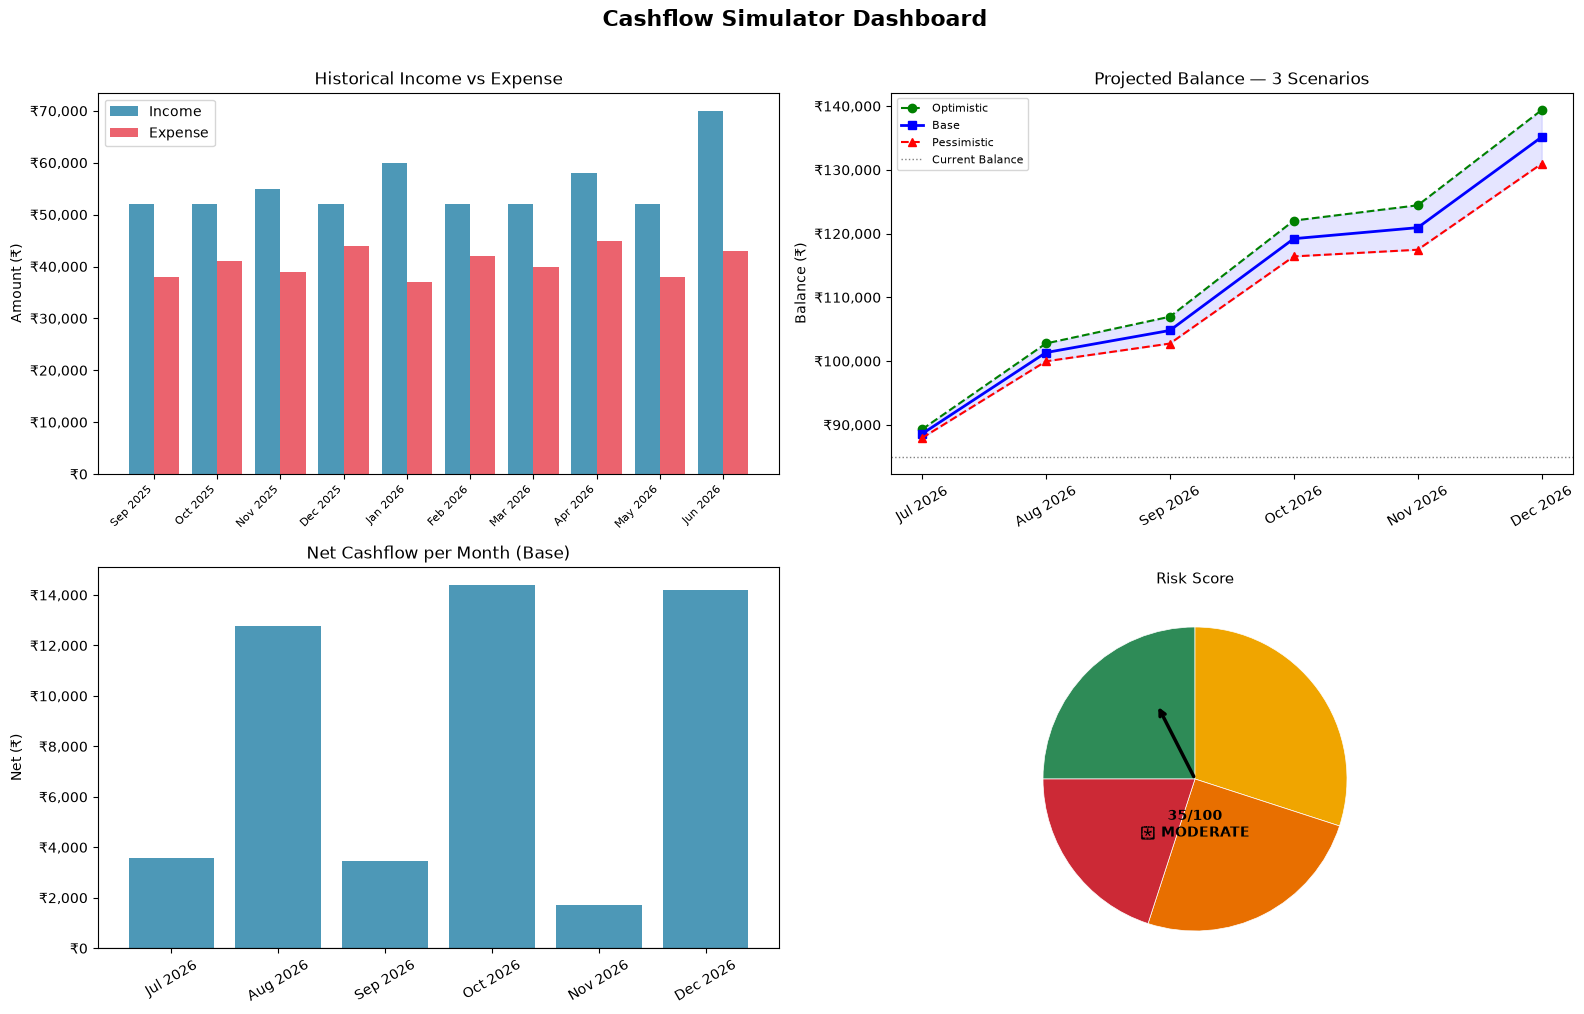

✅ Dashboard saved as cashflow_dashboard.png


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Cashflow Simulator Dashboard', fontsize=16, fontweight='bold', y=1.01)

# ── Plot 1: Historical income vs expense ────────────────────────────────────
ax1 = axes[0, 0]
x = range(len(month_labels))
ax1.bar([i - 0.2 for i in x], income_values,  width=0.4, label='Income',  color='#2e86ab', alpha=0.85)
ax1.bar([i + 0.2 for i in x], expense_values, width=0.4, label='Expense', color='#e84855', alpha=0.85)
ax1.set_xticks(x)
ax1.set_xticklabels(month_labels, rotation=45, ha='right', fontsize=8)
ax1.set_title('Historical Income vs Expense')
ax1.set_ylabel('Amount (₹)')
ax1.legend()
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'₹{int(v):,}'))

# ── Plot 2: Forecasted cashflow with scenarios ───────────────────────────────
ax2 = axes[0, 1]
future_labels = sim.index.tolist()
ax2.plot(future_labels, sim['bal_opt'],  'g--', marker='o', label='Optimistic',   linewidth=1.5)
ax2.plot(future_labels, sim['bal_base'], 'b-',  marker='s', label='Base',         linewidth=2)
ax2.plot(future_labels, sim['bal_pess'], 'r--', marker='^', label='Pessimistic',  linewidth=1.5)
ax2.axhline(y=current_balance, color='gray', linestyle=':', linewidth=1, label='Current Balance')
ax2.fill_between(future_labels, sim['bal_opt'], sim['bal_pess'], alpha=0.1, color='blue')
ax2.set_title('Projected Balance — 3 Scenarios')
ax2.set_ylabel('Balance (₹)')
ax2.legend(fontsize=8)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'₹{int(v):,}'))
ax2.tick_params(axis='x', rotation=30)

# ── Plot 3: Net cashflow by month ────────────────────────────────────────────
ax3 = axes[1, 0]
colors = ['#2e86ab' if v >= 0 else '#e84855' for v in sim['net_base']]
ax3.bar(future_labels, sim['net_base'], color=colors, alpha=0.85)
ax3.axhline(0, color='black', linewidth=0.8)
ax3.set_title('Net Cashflow per Month (Base)')
ax3.set_ylabel('Net (₹)')
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'₹{int(v):,}'))
ax3.tick_params(axis='x', rotation=30)

# ── Plot 4: Risk gauge ───────────────────────────────────────────────────────
ax4 = axes[1, 1]
ax4.axis('off')
risk_score = risk['score']
gauge_colors = ['#2e8b57', '#f0a500', '#e86f00', '#cc2936']
gauge_labels = ['Low\n0-25', 'Moderate\n25-55', 'High\n55-80', 'Critical\n80-100']
gauge_vals   = [25, 30, 25, 20]

wedge_props = {'linewidth': 0.5, 'edgecolor': 'white'}
ax4_inner = fig.add_axes([0.56, 0.05, 0.38, 0.38])
wedges, texts = ax4_inner.pie(
    gauge_vals, colors=gauge_colors,
    startangle=180, counterclock=False,
    wedgeprops=wedge_props
)
ax4_inner.set_aspect('equal')

# Needle
angle_deg = 180 - (risk_score / 100 * 180)
angle_rad = np.radians(angle_deg)
ax4_inner.annotate('', xy=(0.55 * np.cos(angle_rad), 0.55 * np.sin(angle_rad)),
                   xytext=(0, 0),
                   arrowprops=dict(arrowstyle='->', color='black', lw=2.5))
ax4_inner.text(0, -0.3, f"{risk_score}/100\n{risk['rating']}",
               ha='center', va='center', fontsize=10, fontweight='bold')
ax4_inner.set_title('Risk Score', fontsize=11, pad=4)

plt.tight_layout()
plt.savefig('cashflow_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Dashboard saved as cashflow_dashboard.png')

---
## 🤖 STEP 10 — LLM Explanation (Claude via Anthropic API)

In [ ]:
import anthropic

# ── Build structured summary to pass to LLM ─────────────────────────────────
summary = {
    "user_profile": {
        "occupation": occupation,
        "age": age,
        "city": city,
        "dependents": dependents,
        "goal": goal,
        "external_factors": external_factors
    },
    "current_balance_inr": current_balance,
    "historical_avg_income_inr":  round(pd.Series(income_values).mean(), 0),
    "historical_avg_expense_inr": round(pd.Series(expense_values).mean(), 0),
    "forecast_months": forecast_months,
    "projected_balance_base":   {m: int(v) for m, v in sim['bal_base'].items()},
    "projected_balance_opt":    {m: int(v) for m, v in sim['bal_opt'].items()},
    "projected_balance_pess":   {m: int(v) for m, v in sim['bal_pess'].items()},
    "risk_score": risk['score'],
    "risk_rating": risk['rating'],
    "risk_flags": risk['flags'],
    "savings_rate_pct": round(risk['savings_rate'] * 100, 1),
    "emergency_fund_target_inr": int(risk['emergency_target']),
    "min_projected_balance_inr": int(risk['min_projected_balance'])
}

prompt = f"""You are a personal financial advisor for Indian households.
Based on the cashflow simulation data below, write a clear, empathetic, and actionable explanation.

Structure your response:
1. **Summary** (2-3 sentences on financial health)
2. **Key Risks** (bullet points from the risk flags)
3. **Opportunities** (where they can save or grow)
4. **Action Plan** (3-5 concrete monthly steps)
5. **Goal Progress** (assessment of their stated goal: "{goal}")

Use Indian context (INR, Mumbai cost of living, Indian financial products like PPF, SIP, FD).
Keep language simple, warm, and non-judgmental.

DATA:
{json.dumps(summary, indent=2)}
"""

# ── Call Anthropic API ───────────────────────────────────────────────────────
# Set your API key: export ANTHROPIC_API_KEY=sk-ant-...
# Or pass it directly: client = anthropic.Anthropic(api_key='sk-ant-...')

client = anthropic.Anthropic()   # reads ANTHROPIC_API_KEY from env

message = client.messages.create(
    model='claude-sonnet-4-6',
    max_tokens=1024,
    messages=[{'role': 'user', 'content': prompt}]
)

explanation = message.content[0].text
print('=' * 70)
print('🤖 LLM FINANCIAL EXPLANATION')
print('=' * 70)
print(explanation)

---
## 📋 STEP 11 — Full Report Summary

In [ ]:
print('=' * 70)
print(f'CASHFLOW REPORT — {today.strftime("%B %Y")}')
print('=' * 70)
print(f'  Name/Profile  : {occupation}, Age {age}, {city}')
print(f'  Dependents    : {dependents}')
print(f'  Goal          : {goal}')
print(f'  External      : {external_factors}')
print()
print(f'  Current Balance     : ₹{current_balance:,}')
print(f'  Avg Monthly Income  : ₹{int(pd.Series(income_values).mean()):,}')
print(f'  Avg Monthly Expense : ₹{int(monthly_expenses_avg):,}')
print(f'  Savings Rate        : {risk["savings_rate"]:.1%}')
print()
print(f'  Risk Score   : {risk["score"]}/100  ({risk["rating"]})')
print(f'  Emergency Fund Needed : ₹{int(risk["emergency_target"]):,}')
print()
print('  Projected Balances (Base Scenario):')
for month, bal in sim['bal_base'].items():
    print(f'    {month}: ₹{int(bal):,}')
print()
print('  Risk Flags:')
for f in risk['flags']:
    print(f'    {f}')
print('=' * 70)